<table align="center">
  <td align="center"><a target="_blank" href="https://colab.research.google.com/github/sherifmost/DeepLearning/blob/master/Labs/lab1/lab1_part2.ipynb">
        <img src="http://introtodeeplearning.com/images/colab/colab.png?v2.0"  style="padding-bottom:5px;" />Run in Google Colab</a></td>
</table>

# Copyright Information

**Parts of this assignment are based on Kaggle kernels.**

# Assignment 1 - Part2: Logistic Regression

![Logistic Regression](https://raw.githubusercontent.com/KhaledElTahan/AUC-DeepLearning/master/Labs/lab1/logistic_regression.png)

## 1.2.1 Problem Statement

Here, we are trying to increase the people's attention regarding the heart diseases. Like any disease, it is always better to know if you are sick early so you can get the treatment you need before it is too late. Therefore, we use a dataset that gathered some information about two groups: a group with a heart disease and the other group has no disease.
The gathered information includes age, chest pain type, fasting blood sugar, etc.

Your goal is to train a logistic regression model to predict if a person has a heart disease or not depending on the given information.

## 1.2.2 Problem Details

Let's dive into the code, explain it and show you the parts you need to fill!

### 1.2.2.1 Import Needed packages

**Pay close attention to the packages I imported for you**, they will help in the TODOs

In [13]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop
from tensorflow.keras.initializers import RandomNormal, RandomUniform
from tensorflow.keras.losses import BinaryCrossentropy, CategoricalHinge
from tensorflow.keras import regularizers

### 1.2.2.2 Work on the dataset

This dataset contains 13 features that demonstrate the health state of a person and our target (0 if this person does not have a heart disease and 1 if he has a heart disease.)

We first load the dataset.

In [14]:
dataset = pd.read_csv("https://raw.githubusercontent.com/KhaledElTahan/DeepLearning/master/Labs/lab1/lab1_heart.csv")

A sneak peak on the dataset and how it looks like.

In [15]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Define input and output.

In [16]:
X = dataset.iloc[:, 0:13].values
y = dataset.iloc[:, 13].values

**TODO: Preprocess your data**

1.   Do you need to scale the data? Which type of scaling is better?
2.   Try adding non-linearity by including artificial features (**check the FAQs document**).

![The effect of the boundary with artificial features](https://raw.githubusercontent.com/KhaledElTahan/AUC-DeepLearning/master/Labs/lab1/artificial_features_boundaries.png)

You might have a look on part1 preprocessing and take hints from there.

**Try different types of data preprocessing and include their effect on the accuracy in your report.**


**Make sure to add the following to the report:**


*   Include the default case that no data preprocessing is done (2.1 in the report)
*   Try out two different data preprocessing techniques and include them (2.2, 2.3 in the report)
*   Include the default case that no artificial features are added (2.4 in the report)
*   Try out including artificial features (2.5 in the report)



In [17]:
scaler = StandardScaler()
x = scaler.fit_transform(X)

Split dataset into, training, validation and testing splits.

In [18]:
# Get Training Data
train_X, temporary_X, train_y, temporary_y = train_test_split(x, y, train_size=0.75, random_state=0)

# Get Validation & Testing Data
val_X, test_X, val_y, test_y = train_test_split(temporary_X, temporary_y, train_size=0.5, random_state=0)

### 1.2.2.3 Define your model here (TODO)

Logistic Regression as a model is exactly like the Linear Regression except for the activation function.

Use this fact to define your model similar to part1 except for the actication function.

![Logistic Regression using Simple Perceptron](https://raw.githubusercontent.com/KhaledElTahan/AUC-DeepLearning/master/Labs/lab1/perceptron_activation.png)

**TODO**:
1. Try different [activation functions](https://www.tensorflow.org/api_docs/python/tf/keras/activations) and include in the report their effect on the accuracy and the training plot.
2. Try different [regularizers](https://www.tensorflow.org/api_docs/python/tf/keras/regularizers) and include in the report their effect on the accuracy and the training plot.


**Make sure to add the following to the report:**


*   Include the default case that sigmoid activation is used (2.6 in the report)
*   Try out another two activation functions and include them (2.7, 2.8 in the report)
*   Include the default case that no regularizer is added (2.9 in the report)
*   Try out two different regularizers and include them (2.10, 2.11 in the report)

In [19]:
activation = 'sigmoid'
regularizer = regularizers.l2(0.01)

model = Sequential([
    Dense(64, activation=activation, kernel_regularizer=regularizer, input_shape=(train_X.shape[1],)),
    Dense(32, activation=activation, kernel_regularizer=regularizer),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 1.2.2.4 Compile your model and print a summary

**TODO**
1. Try different [losses](https://www.tensorflow.org/api_docs/python/tf/keras/losses) functions and include in the report their effect on the accuracy. Make sure that those losses functions are meant only for classification! Don't use losses functions that are meant for prediction!
2. Try different [optimizers](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) and include in the report their effect on the accuracy and the training plot.

**Make sure to add the following to the report:**


*   Include the default case that Binary Crossentropy loss is used (2.12 in the report)
*   Try out another two losses and include them (2.13, 2.14 in the report)
*   Include the default case that adam optimizer is used (2.15 in the report)
*   Try out another optimizer and include it (2.16 in the report)

In [20]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

loss = BinaryCrossentropy()
optimizer = Adam(learning_rate=0.001)

model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

### 1.2.2.5 Train your model

In [21]:
hist = model.fit(train_X, train_y, verbose=1, validation_data=(val_X, val_y), batch_size=16, epochs=500)

Epoch 1/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5279 - loss: 1.3489 - val_accuracy: 0.5263 - val_loss: 1.2687
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5739 - loss: 1.2405 - val_accuracy: 0.5263 - val_loss: 1.1931
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5528 - loss: 1.1676 - val_accuracy: 0.5263 - val_loss: 1.1252
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6155 - loss: 1.1006 - val_accuracy: 0.7105 - val_loss: 1.0659
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7369 - loss: 1.0538 - val_accuracy: 0.7632 - val_loss: 1.0133
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6760 - loss: 0.9969 - val_accuracy: 0.6842 - val_loss: 0.9677
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7215 - loss: 0.9441 - val_accuracy: 0.6842 - val_loss: 0.9266
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7224 - loss: 0.9185 - val_accuracy: 0.7632 

**The following cell generates the accuracy needed for the report**

Evaluate your testing split, to get the accuracy and the loss score.

In [22]:
score, accuracy = model.evaluate(test_X, test_y, batch_size=16, verbose=0)
print("Test fraction correct (NN-Loss) = {:.2f}".format(score))
print("Test fraction correct (NN-Accuracy) = {:.2f}".format(accuracy))

Test fraction correct (NN-Loss) = 0.46
Test fraction correct (NN-Accuracy) = 0.87


### 1.2.2.6 Visualize Accuracy

**The following cell generates the plots needed for the report**

Plot the training and validation accuracy. Try to interpret those plots.


**TODO: for each experiment you make, include the plot and accuracy in the report and indicate whether there exist any type of *overfitting or underfitting*.**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(train_X, train_y)

y_pred = log_reg.predict(test_X)
y_prob = log_reg.predict_proba(test_X)

loss = log_loss(test_y, y_prob)
acc = accuracy_score(test_y, y_pred)

print("Logistic Regression - Loss:", loss)
print("Logistic Regression - Accuracy:", acc)

Logistic Regression - Loss: 0.3843088316874539
Logistic Regression - Accuracy: 0.868421052631579


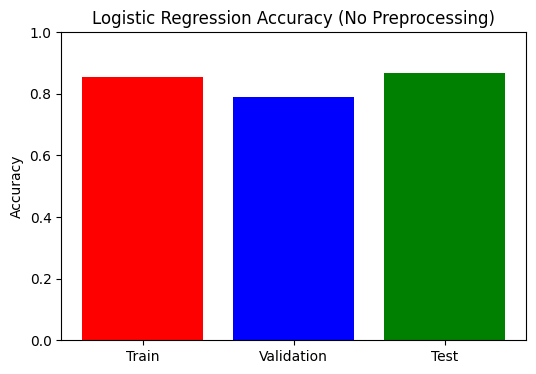

In [29]:
import matplotlib.pyplot as plt

train_acc = log_reg.score(train_X, train_y)
val_acc = log_reg.score(val_X, val_y)
test_acc = acc

plt.figure(figsize=(6,4))
plt.bar(["Train", "Validation", "Test"], [train_acc, val_acc, test_acc], color=['red','blue','green'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Logistic Regression Accuracy (No Preprocessing)")
plt.show()

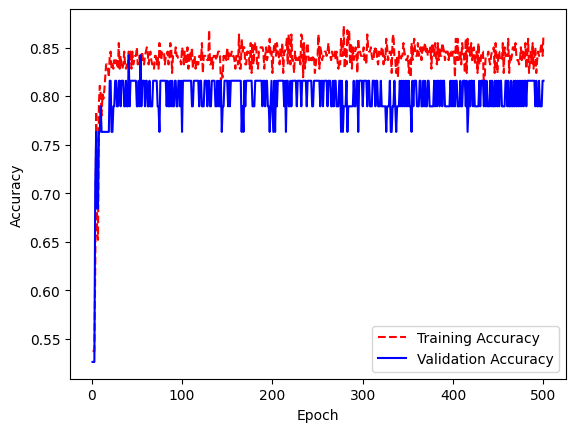

In [23]:
training_loss = hist.history['accuracy']
val_loss = hist.history['val_accuracy']

epoch_count = range(1, len(training_loss) + 1)

plt.figure()
plt.plot(epoch_count, training_loss, 'r--')
plt.plot(epoch_count, val_loss, 'b-')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [45]:
final_val_loss = hist.history['val_loss'][-1]
final_val_acc = hist.history['val_accuracy'][-1]

print("Validation Loss (for table):", final_val_loss)
print("Validation Accuracy (for table):", final_val_acc)

Validation Loss (for table): 0.4887707233428955
Validation Accuracy (for table): 0.8157894611358643


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers

model_mse = Sequential([
    Dense(16, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01), input_shape=(train_X.shape[1],)),
    Dense(1, activation='sigmoid')
])

model_mse.compile(loss=MeanSquaredError(), metrics=['accuracy'], optimizer=SGD(learning_rate=0.01))
model_mse.fit(train_X, train_y, epochs=50, batch_size=16, verbose=0)

loss, acc = model_mse.evaluate(test_X, test_y, verbose=0)
print("NN (MSE Loss) - Loss:", loss)
print("NN (MSE Loss) - Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NN (MSE Loss) - Loss: 0.31658935546875
NN (MSE Loss) - Accuracy: 0.7368420958518982


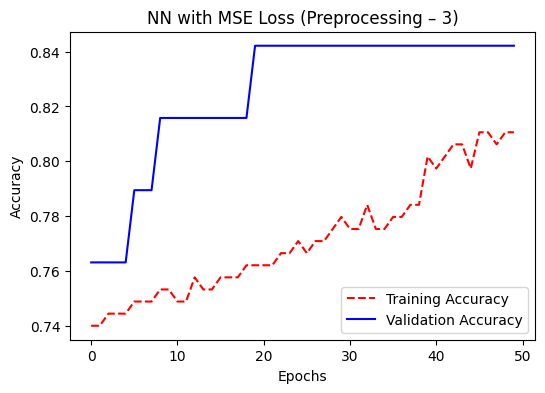

In [30]:
history_mse = model_mse.fit(
    train_X, train_y,
    validation_data=(val_X, val_y),
    epochs=50,
    batch_size=16,
    verbose=0
)

train_acc_hist = history_mse.history['accuracy']
val_acc_hist = history_mse.history['val_accuracy']

plt.figure(figsize=(6,4))
plt.plot(train_acc_hist, 'r--', label="Training Accuracy")
plt.plot(val_acc_hist, 'b-', label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("NN with MSE Loss (Preprocessing – 3)")
plt.legend()
plt.show()

Artificial Features (Poly-2) - Loss: 0.3850018266050516
Artificial Features (Poly-2) - Accuracy: 0.7631578947368421


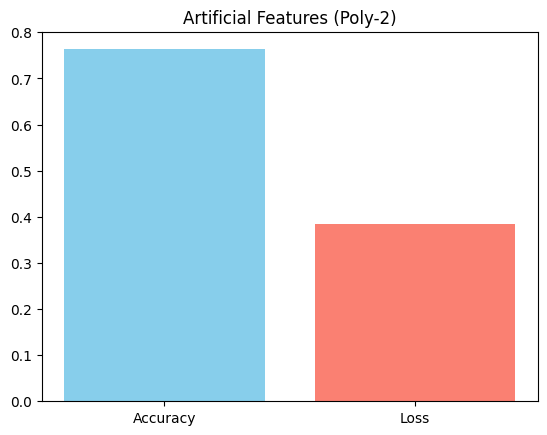

In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
import matplotlib.pyplot as plt

poly = PolynomialFeatures(degree=2, include_bias=False)
train_X_poly = poly.fit_transform(train_X)
test_X_poly = poly.transform(test_X)

log_reg_poly = LogisticRegression(max_iter=1000)
log_reg_poly.fit(train_X_poly, train_y)

y_pred_poly = log_reg_poly.predict(test_X_poly)
y_prob_poly = log_reg_poly.predict_proba(test_X_poly)

loss_poly = log_loss(test_y, y_prob_poly)
acc_poly = accuracy_score(test_y, y_pred_poly)

print("Artificial Features (Poly-2) - Loss:", loss_poly)
print("Artificial Features (Poly-2) - Accuracy:", acc_poly)

plt.figure()
plt.bar(["Accuracy", "Loss"], [acc_poly, loss_poly], color=["skyblue", "salmon"])
plt.title("Artificial Features (Poly-2)")
plt.show()

Artificial Features (Poly-3) - Loss: 0.5402922366595245
Artificial Features (Poly-3) - Accuracy: 0.8421052631578947


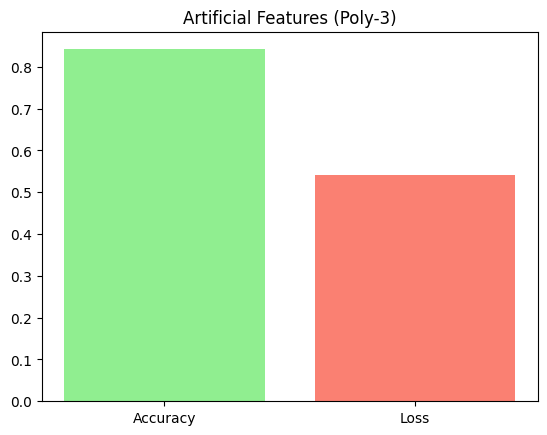

In [32]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
train_X_poly3 = poly3.fit_transform(train_X)
test_X_poly3 = poly3.transform(test_X)

log_reg_poly3 = LogisticRegression(max_iter=1000)
log_reg_poly3.fit(train_X_poly3, train_y)

y_pred_poly3 = log_reg_poly3.predict(test_X_poly3)
y_prob_poly3 = log_reg_poly3.predict_proba(test_X_poly3)

loss_poly3 = log_loss(test_y, y_prob_poly3)
acc_poly3 = accuracy_score(test_y, y_pred_poly3)

print("Artificial Features (Poly-3) - Loss:", loss_poly3)
print("Artificial Features (Poly-3) - Accuracy:", acc_poly3)

plt.figure()
plt.bar(["Accuracy", "Loss"], [acc_poly3, loss_poly3], color=["lightgreen", "salmon"])
plt.title("Artificial Features (Poly-3)")
plt.show()

ReLU - Loss: 0.33738231658935547
ReLU - Accuracy: 0.8947368264198303


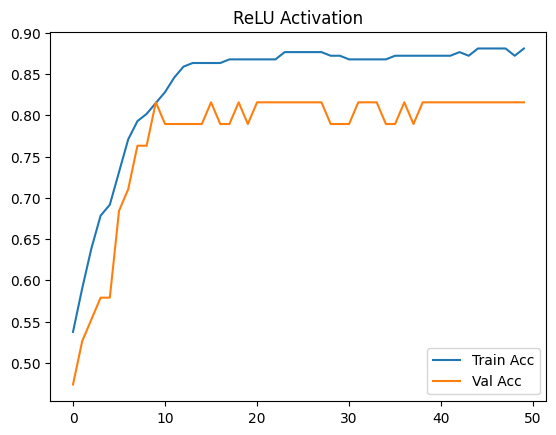

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

model_relu = Sequential([
    Input(shape=(train_X.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_relu.compile(loss=BinaryCrossentropy(), metrics=['accuracy'], optimizer=Adam())
hist_relu = model_relu.fit(train_X, train_y, epochs=50, batch_size=16,
                           validation_data=(val_X, val_y), verbose=0)

loss, acc = model_relu.evaluate(test_X, test_y, verbose=0)
print("ReLU - Loss:", loss)
print("ReLU - Accuracy:", acc)

plt.plot(hist_relu.history['accuracy'], label='Train Acc')
plt.plot(hist_relu.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("ReLU Activation")
plt.show()

Tanh - Loss: 0.3575650751590729
Tanh - Accuracy: 0.8684210777282715


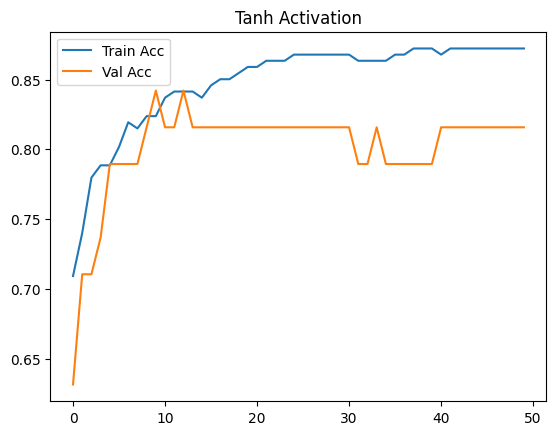

In [34]:
model_tanh = Sequential([
    Input(shape=(train_X.shape[1],)),
    Dense(16, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model_tanh.compile(loss=BinaryCrossentropy(), metrics=['accuracy'], optimizer=Adam())
hist_tanh = model_tanh.fit(train_X, train_y, epochs=50, batch_size=16,
                           validation_data=(val_X, val_y), verbose=0)

loss, acc = model_tanh.evaluate(test_X, test_y, verbose=0)
print("Tanh - Loss:", loss)
print("Tanh - Accuracy:", acc)

plt.plot(hist_tanh.history['accuracy'], label='Train Acc')
plt.plot(hist_tanh.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Tanh Activation")
plt.show()

No Regularizer - Loss: 0.3789595663547516
No Regularizer - Accuracy: 0.8421052694320679


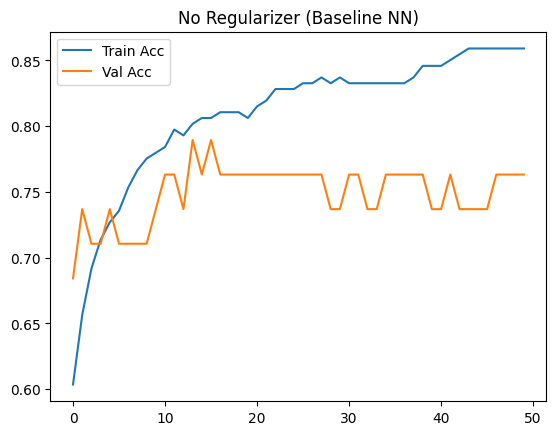

In [35]:
model_noreg = Sequential([
    Input(shape=(train_X.shape[1],)),
    Dense(16, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

model_noreg.compile(loss=BinaryCrossentropy(), metrics=['accuracy'], optimizer=Adam())
hist_noreg = model_noreg.fit(train_X, train_y, epochs=50, batch_size=16,
                             validation_data=(val_X, val_y), verbose=0)

loss, acc = model_noreg.evaluate(test_X, test_y, verbose=0)
print("No Regularizer - Loss:", loss)
print("No Regularizer - Accuracy:", acc)

plt.plot(hist_noreg.history['accuracy'], label='Train Acc')
plt.plot(hist_noreg.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("No Regularizer (Baseline NN)")
plt.show()

Dropout Regularizer - Loss: 0.3765980005264282
Dropout Regularizer - Accuracy: 0.8684210777282715


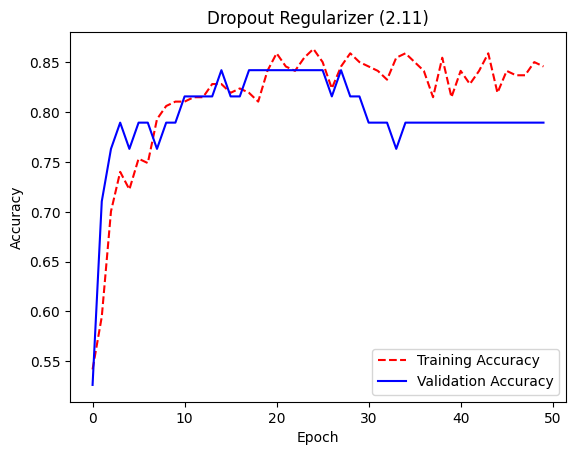

In [38]:
from tensorflow.keras.layers import Dropout

model_reg3 = Sequential([
    Dense(64, activation='sigmoid', input_shape=(train_X.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

model_reg3.compile(loss=BinaryCrossentropy(), optimizer=Adam(), metrics=['accuracy'])
hist_reg3 = model_reg3.fit(train_X, train_y, validation_data=(val_X, val_y),
                           epochs=50, batch_size=16, verbose=0)

loss, acc = model_reg3.evaluate(test_X, test_y, verbose=0)
print("Dropout Regularizer - Loss:", loss)
print("Dropout Regularizer - Accuracy:", acc)

plt.figure()
plt.plot(hist_reg3.history['accuracy'], 'r--')
plt.plot(hist_reg3.history['val_accuracy'], 'b-')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Dropout Regularizer (2.11)")
plt.show()

NN (Hinge Loss) - Loss: 0.27001866698265076
NN (Hinge Loss) - Accuracy: 0.8947368264198303


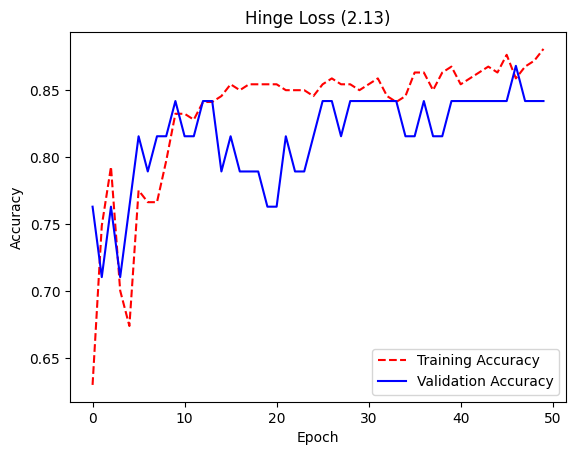

In [40]:
from tensorflow.keras.losses import Hinge

model_hinge = Sequential([
    Dense(64, activation='sigmoid', input_shape=(train_X.shape[1],)),
    Dense(32, activation='sigmoid'),
    Dense(1, activation='tanh')
])

model_hinge.compile(loss=Hinge(), optimizer=Adam(), metrics=['accuracy'])
hist_hinge = model_hinge.fit(train_X, train_y, validation_data=(val_X, val_y),
                             epochs=50, batch_size=16, verbose=0)

loss, acc = model_hinge.evaluate(test_X, test_y, verbose=0)
print("NN (Hinge Loss) - Loss:", loss)
print("NN (Hinge Loss) - Accuracy:", acc)

plt.figure()
plt.plot(hist_hinge.history['accuracy'], 'r--')
plt.plot(hist_hinge.history['val_accuracy'], 'b-')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Hinge Loss (2.13)")
plt.show()

NN (Categorical Hinge Loss) - Loss: 0.2702352702617645
NN (Categorical Hinge Loss) - Accuracy: 0.8947368264198303


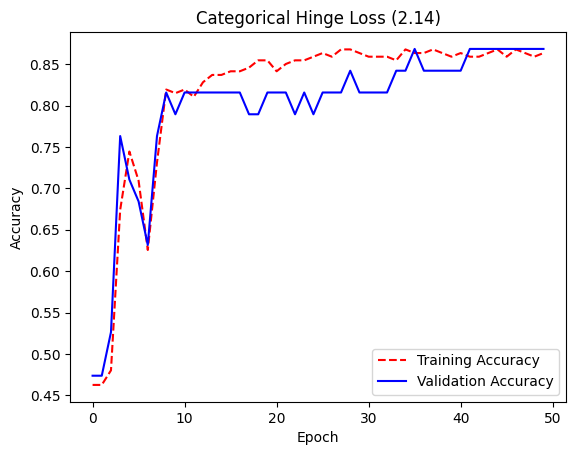

In [41]:
from tensorflow.keras.losses import CategoricalHinge

model_cathinge = Sequential([
    Dense(64, activation='sigmoid', input_shape=(train_X.shape[1],)),
    Dense(32, activation='sigmoid'),
    Dense(1, activation='tanh')
])

model_cathinge.compile(loss=CategoricalHinge(), optimizer=Adam(), metrics=['accuracy'])
hist_cathinge = model_cathinge.fit(train_X, train_y, validation_data=(val_X, val_y),
                                   epochs=50, batch_size=16, verbose=0)

loss, acc = model_cathinge.evaluate(test_X, test_y, verbose=0)
print("NN (Categorical Hinge Loss) - Loss:", loss)
print("NN (Categorical Hinge Loss) - Accuracy:", acc)

plt.figure()
plt.plot(hist_cathinge.history['accuracy'], 'r--')
plt.plot(hist_cathinge.history['val_accuracy'], 'b-')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Categorical Hinge Loss (2.14)")
plt.show()

NN (SGD Optimizer) - Loss: 0.6126452088356018
NN (SGD Optimizer) - Accuracy: 0.7631579041481018


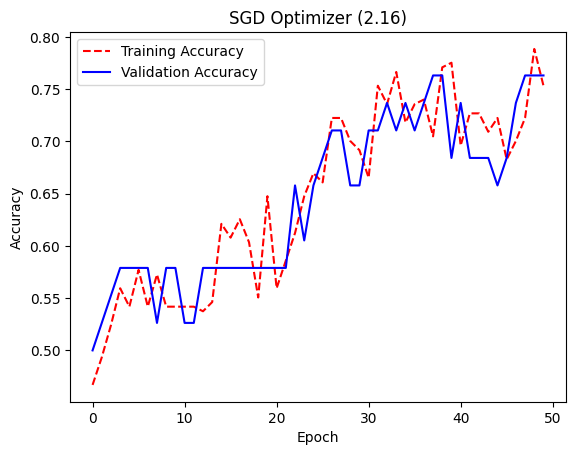

In [42]:
model_sgd = Sequential([
    Dense(64, activation='sigmoid', input_shape=(train_X.shape[1],)),
    Dense(32, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

model_sgd.compile(loss=BinaryCrossentropy(), optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])
hist_sgd = model_sgd.fit(train_X, train_y, validation_data=(val_X, val_y),
                         epochs=50, batch_size=16, verbose=0)

loss, acc = model_sgd.evaluate(test_X, test_y, verbose=0)
print("NN (SGD Optimizer) - Loss:", loss)
print("NN (SGD Optimizer) - Accuracy:", acc)

plt.figure()
plt.plot(hist_sgd.history['accuracy'], 'r--')
plt.plot(hist_sgd.history['val_accuracy'], 'b-')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("SGD Optimizer (2.16)")
plt.show()

## 1.2.3 Conclusion

That's it! Congratulations on training a logistic regression model.

Make sure you deliver all the requirements for the submission.